# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [2]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 13.44 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
!ls MNIST

processed  raw


In [4]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [5]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [6]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

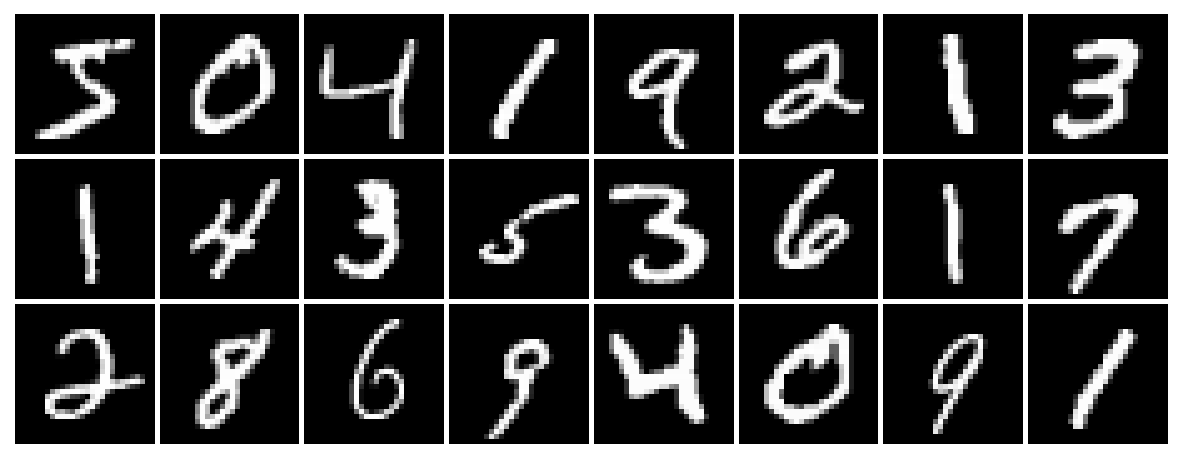

In [7]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


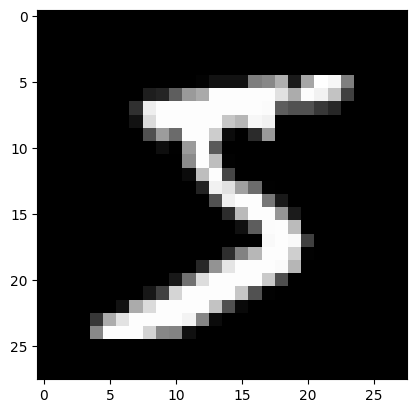

In [8]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [9]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [10]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.0394, -0.2866, -0.1062,  0.1348, -0.2340, -0.2355, -0.0670,  0.0485,
          0.0184, -0.0486],
        [-0.1029, -0.2264,  0.0564,  0.2143, -0.5317, -0.4178, -0.3713,  0.0968,
         -0.1266, -0.1238],
        [-0.1420,  0.1597,  0.0920,  0.1157, -0.0932, -0.1528,  0.1049,  0.0093,
          0.0338,  0.0268],
        [-0.0890, -0.0882,  0.0442, -0.0521, -0.0713, -0.1712, -0.1044, -0.0935,
         -0.2738,  0.2729],
        [-0.2360, -0.1946,  0.2331,  0.2668,  0.0269, -0.1592,  0.1010,  0.0978,
         -0.4848, -0.0706]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [11]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [12]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    # EXERCÍCIO 1 — imprime época, perda e acurácia no final de cada época
    _, predicts = torch.max(outputs, 1)
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.4f}'.format(
        i + 1, epochs, loss.item(), accuracy))

    # EXERCÍCIO 2 — imprime os gradientes do neurônio da classe 4
    # model.weight.grad tem shape (10, 784): uma linha por classe
    # A linha de índice 4 corresponde ao neurônio da classe "dígito 4"
    grad_classe4 = model.weight.grad[4]  # shape: (784,)
    print('  Gradiente dígito 4 — min: {:.6f} | max: {:.6f} | média: {:.6f}'.format(
        grad_classe4.min().item(),
        grad_classe4.max().item(),
        grad_classe4.mean().item()
    ))

Epoch[1/100], loss: 2.324250, acc: 0.0640
  Gradiente dígito 4 — min: -0.050026 | max: 0.038257 | média: -0.001133
Epoch[2/100], loss: 1.817460, acc: 0.5850
  Gradiente dígito 4 — min: -0.040245 | max: 0.040180 | média: 0.000404
Epoch[3/100], loss: 1.482100, acc: 0.7340
  Gradiente dígito 4 — min: -0.036461 | max: 0.032446 | média: -0.000559
Epoch[4/100], loss: 1.260122, acc: 0.7760
  Gradiente dígito 4 — min: -0.029093 | max: 0.030901 | média: 0.000233
Epoch[5/100], loss: 1.108327, acc: 0.8010
  Gradiente dígito 4 — min: -0.026383 | max: 0.025850 | média: -0.000344
Epoch[6/100], loss: 0.996834, acc: 0.8160
  Gradiente dígito 4 — min: -0.020571 | max: 0.024951 | média: 0.000377
Epoch[7/100], loss: 0.914395, acc: 0.8280
  Gradiente dígito 4 — min: -0.020087 | max: 0.020980 | média: -0.000221
Epoch[8/100], loss: 0.850911, acc: 0.8370
  Gradiente dígito 4 — min: -0.016169 | max: 0.020252 | média: 0.000238
Epoch[9/100], loss: 0.800270, acc: 0.8400
  Gradiente dígito 4 — min: -0.015526 | ma

### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [13]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # ── Treino ──────────────────────────────────────────────────────────────
    model.train()
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # ── Validação ────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()

    val_losses.append(loss_val.item())
    val_accuracies.append(accuracy_val)

    # EXERCÍCIO 1 — print por época (treino + validação)
    print('Epoch[{}/{}]  train_loss: {:.4f}  train_acc: {:.4f}  val_loss: {:.4f}  val_acc: {:.4f}'.format(
        i + 1, epochs,
        loss_train.item(), accuracy_train,
        loss_val.item(), accuracy_val
    ))

    # EXERCÍCIO 2 — gradiente da classe 4 (calculado durante o backward do treino)
    grad_classe4 = model.weight.grad[4]
    print('  Grad dígito 4 — min: {:.6f} | max: {:.6f} | norm L2: {:.6f}'.format(
        grad_classe4.min().item(),
        grad_classe4.max().item(),
        grad_classe4.norm().item()
    ))

Epoch[1/100]  train_loss: 0.2643  train_acc: 0.9410  val_loss: 0.3930  val_acc: 0.9050
  Grad dígito 4 — min: -0.003328 | max: 0.002469 | norm L2: 0.016435
Epoch[2/100]  train_loss: 0.2630  train_acc: 0.9410  val_loss: 0.3920  val_acc: 0.9050
  Grad dígito 4 — min: -0.003306 | max: 0.002449 | norm L2: 0.016330
Epoch[3/100]  train_loss: 0.2617  train_acc: 0.9420  val_loss: 0.3911  val_acc: 0.9050
  Grad dígito 4 — min: -0.003285 | max: 0.002429 | norm L2: 0.016226
Epoch[4/100]  train_loss: 0.2604  train_acc: 0.9440  val_loss: 0.3902  val_acc: 0.9050
  Grad dígito 4 — min: -0.003263 | max: 0.002409 | norm L2: 0.016124
Epoch[5/100]  train_loss: 0.2591  train_acc: 0.9440  val_loss: 0.3893  val_acc: 0.9050
  Grad dígito 4 — min: -0.003242 | max: 0.002390 | norm L2: 0.016023
Epoch[6/100]  train_loss: 0.2579  train_acc: 0.9440  val_loss: 0.3884  val_acc: 0.9100
  Grad dígito 4 — min: -0.003221 | max: 0.002372 | norm L2: 0.015925
Epoch[7/100]  train_loss: 0.2566  train_acc: 0.9440  val_loss: 0

### Por que `model.weight.grad[4]`?

Após `loss.backward()`, o PyTorch deposita em `model.weight.grad` o gradiente
de toda a camada Linear, com shape **(10 × 784)** — uma linha por classe,
uma coluna por pixel de entrada.

- **Linha 4** → neurônio responsável por reconhecer o dígito "4"
- O gradiente indica **quanto cada pixel contribuiu para o erro** do dígito 4
- Gradientes com **grande magnitude** → pixels muito influentes naquela época
- **Norma L2** do gradiente resume a "força" da atualização daquele neurônio

> ⚠️ O `model.weight.grad` é zerado no início de cada época com `optimizer.zero_grad()`.
> Por isso, o print deve vir **após** `loss.backward()` e **antes** de `optimizer.zero_grad()`
> da próxima época.

In [14]:
print('Final loss:', loss.item())

Final loss: 0.2656537592411041


### Visualizando gráfico de perda durante o treinamento

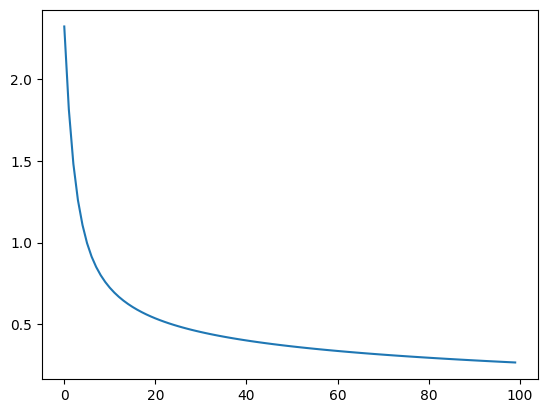

In [15]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

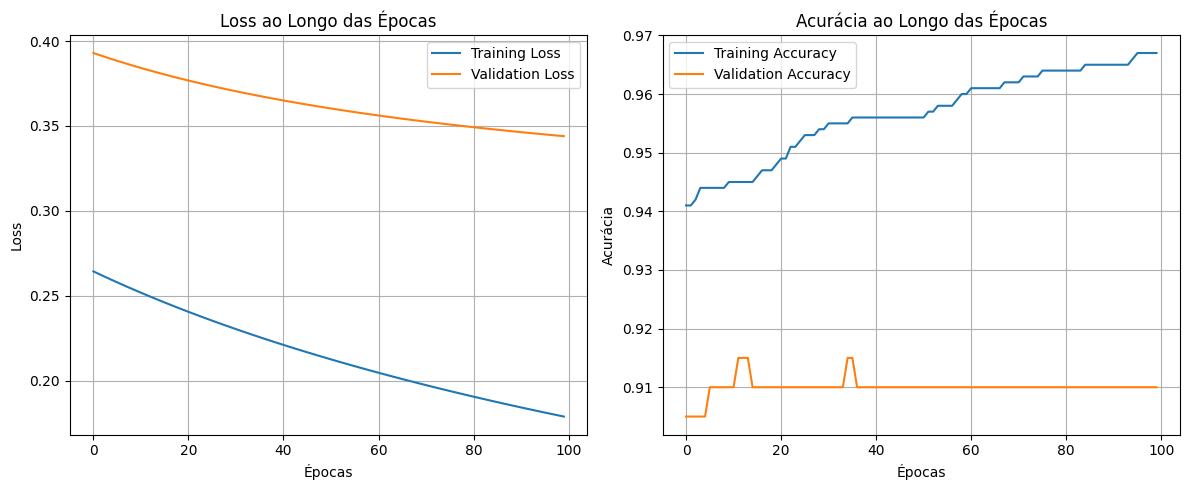

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [17]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [18]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


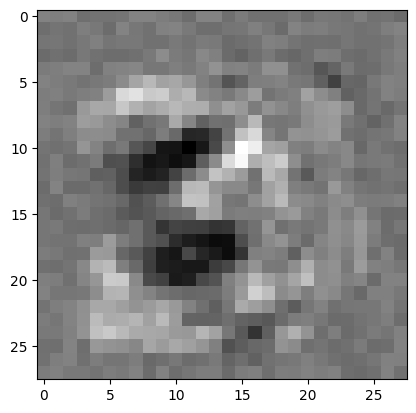

In [19]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

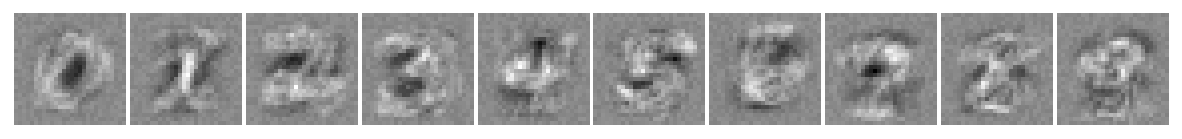

In [20]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede? R: O shape da entrada é (1000 × 784) — 1000 amostras, cada uma com 784 atributos (pixels).

2. Qual é o shape da saída da rede? O modelo tem 10 neurônios de saída (um por dígito, de 0 a 9): O shape da saída é (1000 × 10) — 1000 amostras, cada uma com 10 logits (scores brutos, antes do Softmax).

3. Qual é o número total de parâmetros da rede, incluindo o bias? R: 7.840